In [2]:
import json
import pandas as pd
import numpy as np
from IPython.display import display

RESULTS_PATH = "generation_results.json"
GROUND_TRUTH_PATH = "ground_truth.json"

print("📊 Запуск раздельной генерации таблиц (Stage 1 & Stage 2)...\n")

with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    results_data = json.load(f)
with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    gt_data = {str(item['id']): item for item in json.load(f)}

categories = ["explicit", "semi-explicit", "implicit", "anomalous"]
modes = ["Baseline", "GeoGraphRAG", "VectorRAG"]

accum = {cat: {mode: {} for mode in modes} for cat in categories}

# ==========================================
# 1. СБОР И РАСЧЕТ ВСЕХ ДАННЫХ
# ==========================================
for model_data in results_data:
    model_name = model_data["model"]
    
    for cat in categories:
        for mode in modes:
            accum[cat][mode][model_name] = {
                "exec": [], "syntax": [], "map": [], "latency": [],
                "prec": [], "rec": [], "f1": [], "triples": []
            }
            
    for item in model_data["metrics"]:
        q_id = str(item.get("query_id"))
        raw_cat = item.get("category", "unknown").lower()
        cat = "anomalous" if "anomal" in raw_cat else raw_cat
        if cat not in categories: continue
            
        # Общие метрики генерации (для всех)
        for mode in modes:
            m_data = item.get(mode, {})
            if m_data:
                accum[cat][mode][model_name]["exec"].append(1 if m_data.get("exec") else 0)
                accum[cat][mode][model_name]["map"].append(1 if m_data.get("has_map") else 0)
                if m_data.get("latency") is not None:
                    accum[cat][mode][model_name]["latency"].append(m_data.get("latency"))
                    
        # Графовые метрики (только для GeoGraphRAG и только для релевантных запросов)
        if cat != "anomalous":
            rag_data = item.get("GeoGraphRAG", {})
            retrieval = rag_data.get("retrieval", {})
            
            if retrieval and retrieval.get("status") != "no_ground_truth":
                t_found = retrieval.get("targets_found", 0)
                t_total = retrieval.get("retrieved_total", 0)
                eer = retrieval.get("eer", 0.0)
                triples = rag_data.get("triples", 0)
                
                accum[cat]["GeoGraphRAG"][model_name]["triples"].append(triples)
                
                expected_count = len(gt_data.get(q_id, {}).get("expected_entities", []))
                seed_nodes = t_total / (1 + eer) if (1 + eer) > 0 else t_total
                
                rec = t_found / expected_count if expected_count > 0 else 0.0
                prec = min(1.0, t_found / seed_nodes if seed_nodes > 0 else 0.0)
                f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
                
                accum[cat]["GeoGraphRAG"][model_name]["rec"].append(rec)
                accum[cat]["GeoGraphRAG"][model_name]["prec"].append(prec)
                accum[cat]["GeoGraphRAG"][model_name]["f1"].append(f1)

# ==========================================
# 2. ГЕНЕРАЦИЯ ТАБЛИЦ STAGE 1 (End-to-End)
# ==========================================
print("🏆 ЭТАП 1: Сравнение конечного результата (End-to-End)\n" + "-"*50)

for cat in categories:
    rows = []
    # Собираем все 3 режима в одну таблицу
    for mode in modes:
        display_mode = "HydroGraphRAG" if mode == "GeoGraphRAG" else mode
        for model in accum[cat][mode]:
            d = accum[cat][mode][model]
            rows.append({
                "Архитектура": display_mode,
                "Модель LLM": model,
                "ESR (Успешный код)": np.mean(d["exec"]) if d["exec"] else 0,
                "Map Rate (Карта)": np.mean(d["map"]) if d["map"] else 0,
                "Latency (s)": np.mean(d["latency"]) if d["latency"] else 0
            })
            
    df_stage1 = pd.DataFrame(rows).round(3)
    
    # Сортировка: сначала по архитектуре (чтобы красиво смотрелось), потом по ESR
    if cat == "anomalous":
        df_stage1 = df_stage1.sort_values(by=["Архитектура", "ESR (Успешный код)"], ascending=[True, True]).reset_index(drop=True)
    else:
        df_stage1 = df_stage1.sort_values(by=["Архитектура", "ESR (Успешный код)"], ascending=[True, False]).reset_index(drop=True)
        
    df_stage1.to_csv(f"stage1_end2end_{cat}.csv", index=False)
    
    print(f"🔹 Категория: {cat.upper()}")
    display(df_stage1)
    print("\n")

# ==========================================
# 3. ГЕНЕРАЦИЯ ТАБЛИЦ STAGE 2 (Анализ Графа)
# ==========================================
print("🔬 ЭТАП 2: Внутренние метрики графового ретривера (Только HydroGraphRAG)\n" + "-"*50)

# Для аномалий графовые метрики не считаем (нет ground truth)
graph_categories = ["explicit", "semi-explicit", "implicit"]

for cat in graph_categories:
    rows = []
    for model in accum[cat]["GeoGraphRAG"]:
        d = accum[cat]["GeoGraphRAG"][model]
        rows.append({
            "Модель LLM": model,
            "Entity Precision": np.mean(d["prec"]) if d["prec"] else 0,
            "Entity Recall (TDR)": np.mean(d["rec"]) if d["rec"] else 0,
            "Entity F1": np.mean(d["f1"]) if d["f1"] else 0,
            "Avg Triples (Связи)": np.mean(d["triples"]) if d["triples"] else 0
        })
        
    df_stage2 = pd.DataFrame(rows).round(3)
    df_stage2 = df_stage2.sort_values(by="Entity F1", ascending=False).reset_index(drop=True)
    
    df_stage2.to_csv(f"stage2_graph_{cat}.csv", index=False)
    
    print(f"🔹 Категория: {cat.upper()}")
    display(df_stage2)
    print("\n")

print("✅ Генерация завершена! CSV файлы сохранены.")

📊 Запуск раздельной генерации таблиц (Stage 1 & Stage 2)...

🏆 ЭТАП 1: Сравнение конечного результата (End-to-End)
--------------------------------------------------
🔹 Категория: EXPLICIT


,Архитектура,Модель LLM,ESR (Успешный код),Map Rate (Карта),Latency (s)
0,Baseline,gemma4:31b,0.850,0.850,32.624
1,Baseline,qwen2.5-coder:7b,0.617,0.600,3.252
2,Baseline,llama3.1:8b,0.317,0.317,2.823
3,Baseline,qwen2.5-coder:32b,0.250,0.250,12.898
4,Baseline,gemma2:27b,0.050,0.050,8.315
5,Baseline,mistral-nemo,0.050,0.050,63.842
6,Baseline,codestral,0.000,0.000,6.242
7,HydroGraphRAG,qwen2.5-coder:7b,1.000,1.000,5.202
8,HydroGraphRAG,qwen2.5-coder:32b,1.000,1.000,13.646
9,HydroGraphRAG,gemma2:27b,1.000,1.000,10.451




🔹 Категория: SEMI-EXPLICIT


,Архитектура,Модель LLM,ESR (Успешный код),Map Rate (Карта),Latency (s)
0,Baseline,gemma4:31b,0.743,0.730,31.918
1,Baseline,qwen2.5-coder:32b,0.405,0.405,13.387
2,Baseline,qwen2.5-coder:7b,0.351,0.351,3.449
3,Baseline,llama3.1:8b,0.189,0.189,2.851
4,Baseline,mistral-nemo,0.095,0.095,59.298
5,Baseline,gemma2:27b,0.027,0.027,7.784
6,Baseline,codestral,0.000,0.000,6.334
7,HydroGraphRAG,qwen2.5-coder:7b,1.000,1.000,6.110
8,HydroGraphRAG,qwen2.5-coder:32b,1.000,1.000,16.330
9,HydroGraphRAG,gemma2:27b,1.000,1.000,11.720




🔹 Категория: IMPLICIT


...



🔹 Категория: SEMI-EXPLICIT


,Модель LLM,Entity Precision,Entity Recall (TDR),Entity F1,Avg Triples (Связи)
0,gemma4:31b,0.878,0.842,0.854,105.959
1,gemma2:27b,0.851,0.838,0.842,105.014
2,codestral,0.865,0.831,0.842,108.311
3,qwen2.5-coder:7b,0.797,0.797,0.797,101.311
4,qwen2.5-coder:32b,0.770,0.757,0.761,92.162
5,mistral-nemo,0.554,0.547,0.550,74.676
6,llama3.1:8b,0.000,0.000,0.000,0.000




🔹 Категория: IMPLICIT


,Модель LLM,Entity Precision,Entity Recall (TDR),Entity F1,Avg Triples (Связи)
0,codestral,0.658,0.605,0.623,64.474
1,gemma2:27b,0.605,0.572,0.583,66.842
2,gemma4:31b,0.553,0.507,0.522,55.132
3,qwen2.5-coder:32b,0.487,0.447,0.461,52.105
4,mistral-nemo,0.474,0.454,0.461,49.303
5,qwen2.5-coder:7b,0.421,0.421,0.421,48.421
6,llama3.1:8b,0.000,0.000,0.000,0.000




✅ Генерация завершена! CSV файлы сохранены.


In [3]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
# All files are assumed to be in the current working directory
FINAL_EVAL_PATH = "final_evaluation_results.json"
GROUND_TRUTH_PATH = "ground_truth.json"

print("Loading data...")
with open(FINAL_EVAL_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    gt_data = {str(item['id']): item for item in json.load(f)}

categories =["explicit", "semi-explicit", "implicit", "anomalous"]
architectures =["Baseline", "VectorRAG", "GeoGraphRAG"]
records =[]

# ==========================================
# 2. DATA PARSING & METRICS CALCULATION
# ==========================================
print("Processing metrics...")
for run in data:
    model_name = run.get("model", "unknown")
    
    for metric in run.get("metrics",[]):
        q_id = str(metric.get("query_id"))
        raw_cat = metric.get("category", "unknown").lower()
        cat = "anomalous" if "anomal" in raw_cat else raw_cat
        if cat not in categories: continue
            
        for arch in architectures:
            if arch in metric:
                arch_data = metric[arch]
                display_arch = 'HydroGraphRAG' if arch == 'GeoGraphRAG' else arch
                
                # Base Metrics
                record = {
                    'Model': model_name,
                    'Category': cat.capitalize(),
                    'Architecture': display_arch,
                    'ESR': 1 if arch_data.get('exec') else 0,
                    'Map_Rate': 1 if arch_data.get('has_map', False) else 0,
                    'Latency': arch_data.get('latency', 0),
                    'Faithfulness': arch_data.get('faithfulness_score', np.nan),
                    'Semantic': arch_data.get('semantic_score', np.nan),
                    'Structural': arch_data.get('structural_score', np.nan)
                }
                
                # Graph Retrieval Metrics (Only for HydroGraphRAG & Valid Queries)
                if arch == "GeoGraphRAG" and cat != "anomalous":
                    retrieval = arch_data.get("retrieval", {})
                    if retrieval and retrieval.get("status") != "no_ground_truth":
                        t_found = retrieval.get("targets_found", 0)
                        t_total = retrieval.get("retrieved_total", 0)
                        eer = retrieval.get("eer", 0.0)
                        
                        expected_count = len(gt_data.get(q_id, {}).get("expected_entities",[]))
                        seed_nodes = t_total / (1 + eer) if (1 + eer) > 0 else t_total
                        
                        rec = t_found / expected_count if expected_count > 0 else 0.0
                        prec = min(1.0, t_found / seed_nodes if seed_nodes > 0 else 0.0)
                        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
                        
                        record['Triples'] = arch_data.get("triples", 0)
                        record['Recall_TDR'] = rec
                        record['Precision'] = prec
                        record['F1_Score'] = f1
                
                records.append(record)

df = pd.DataFrame(records)

# ==========================================
# 3. LATEX TABLE GENERATION
# ==========================================
print("\n" + "="*50)
print("GENERATING LATEX TABLES (IEEE FORMAT)")
print("="*50)

# Table 1: ESR and Map Rate
tab1 = df.groupby(['Category', 'Architecture'])[['ESR', 'Map_Rate']].mean().round(3)
print("\n% --- LATEX: TABLE I. Execution Success Rate ---")
print(tab1.to_latex(column_format="llcc", caption="Execution Success Rate (ESR) and Map Generation Rate across different architectural configurations.", label="tab:esr_metrics"))

# Table 2: LLM-as-a-Judge
tab2 = df.groupby(['Category', 'Architecture'])[['Faithfulness', 'Semantic', 'Structural']].mean().round(3)
print("\n% --- LATEX: TABLE II. LLM-as-a-Judge Evaluation ---")
print(tab2.to_latex(column_format="llccc", caption="Qualitative assessment by the automated LLM Judge (Qwen2.5-Coder 32B). Scores range from 1 to 5.", label="tab:judge_metrics"))

# Table 3: Graph Metrics by Model (Explicit & Semi-explicit averaged)
df_graph = df[(df['Architecture'] == 'HydroGraphRAG') & (df['Category'].isin(['Explicit', 'Semi-explicit']))]
tab3 = df_graph.groupby(['Model'])[['Precision', 'Recall_TDR', 'F1_Score', 'Triples']].mean().round(3).sort_values(by="F1_Score", ascending=False)
print("\n% --- LATEX: TABLE III. Graph Retrieval Metrics by Model ---")
print(tab3.to_latex(column_format="lcccc", caption="Topological retrieval accuracy across different LLMs operating within the HydroGraphRAG framework.", label="tab:graph_metrics"))


# ==========================================
# 4. HIGH-QUALITY IEEE PLOTS GENERATION
# ==========================================
print("\nGenerating High-Resolution Plots for the paper...")

# Apply Academic Styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16,            # Базовый шрифт увеличен
    'axes.titlesize': 20,       # Заголовки графиков (Огромные)
    'axes.labelsize': 18,       # Подписи осей X и Y
    'xtick.labelsize': 16,      # Названия моделей (Qwen, Gemma и т.д.)
    'ytick.labelsize': 16,      # Цифры на оси Y
    'legend.fontsize': 14,      # Текст легенды
    'legend.title_fontsize': 16 # Заголовок легенды
})

# PLOT 1: ESR Comparison
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x='Category', y='ESR', hue='Architecture', data=df, palette='viridis', errorbar=None)
plt.title('Execution Success Rate (ESR) by Query Category', fontweight='bold', pad=15)
plt.ylabel('Execution Success Rate')
plt.xlabel('Query Category')
plt.ylim(0, 1.1)
plt.legend(title='Architecture', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig('Fig1_ESR_Comparison.png', dpi=300)
plt.close()

# PLOT 2: Faithfulness (Hallucination Mitigation)
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='Category', y='Faithfulness', hue='Architecture', data=df, palette='rocket_r', errorbar=None)
plt.title('Faithfulness Score (Hallucination Mitigation)', fontweight='bold', pad=15)
plt.ylabel('Score (1 to 5)')
plt.xlabel('Query Category')
plt.ylim(0, 5.5)
plt.legend(title='Architecture', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig('Fig2_Faithfulness_Mitigation.png', dpi=300)
plt.close()

# PLOT 3: The "Cognitive-Syntactic Gap" (Codestral Anomaly)
# We plot Graph F1-Score vs Code ESR for HydroGraphRAG Explicit queries
df_anomaly = df[(df['Architecture'] == 'HydroGraphRAG') & (df['Category'] == 'Explicit')]
anomaly_stats = df_anomaly.groupby('Model')[['F1_Score', 'ESR']].mean().reset_index()

x = np.arange(len(anomaly_stats['Model']))
width = 0.35

fig, ax3 = plt.subplots(figsize=(12, 6))
rects1 = ax3.bar(x - width/2, anomaly_stats['F1_Score'], width, label='Graph Retrieval Accuracy (F1-Score)', color='#2ca02c')
rects2 = ax3.bar(x + width/2, anomaly_stats['ESR'], width, label='Code Execution Success (ESR)', color='#1f77b4')

ax3.set_ylabel('Score (0.0 to 1.0)', fontweight='bold')
ax3.set_title('The Cognitive-Syntactic Gap: Retrieval Accuracy vs. Execution Reliability', fontweight='bold', pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(anomaly_stats['Model'], rotation=30, ha='right')
ax3.legend(loc='upper right')

# Add values on top
ax3.bar_label(rects1, fmt='%.2f', padding=3, fontsize=10)
ax3.bar_label(rects2, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig('Fig3_Cognitive_Syntactic_Gap.png', dpi=300)
plt.close()

print("✅ DONE! All LaTeX tables printed to console.")
print("✅ DONE! High-resolution plots saved as PNG files (Fig1, Fig2, Fig3) in the current directory.")

Loading data...
Processing metrics...

GENERATING LATEX TABLES (IEEE FORMAT)

% --- LATEX: TABLE I. Execution Success Rate ---
\begin{table}
\caption{Execution Success Rate (ESR) and Map Generation Rate across different architectural configurations.}
\label{tab:esr_metrics}
\begin{tabular}{llcc}
\toprule
 &  & ESR & Map_Rate \\
Category & Architecture &  &  \\
\midrule
\multirow[t]{3}{*}{Anomalous} & Baseline & 0.354000 & 0.356000 \\
 & HydroGraphRAG & 0.004000 & 0.004000 \\
 & VectorRAG & 0.421000 & 0.423000 \\
\cline{1-4}
\multirow[t]{3}{*}{Explicit} & Baseline & 0.305000 & 0.302000 \\
 & HydroGraphRAG & 0.864000 & 0.864000 \\
 & VectorRAG & 0.412000 & 0.410000 \\
\cline{1-4}
\multirow[t]{3}{*}{Implicit} & Baseline & 0.216000 & 0.224000 \\
 & HydroGraphRAG & 0.846000 & 0.846000 \\
 & VectorRAG & 0.395000 & 0.397000 \\
\cline{1-4}
\multirow[t]{3}{*}{Semi-explicit} & Baseline & 0.259000 & 0.257000 \\
 & HydroGraphRAG & 0.851000 & 0.851000 \\
 & VectorRAG & 0.409000 & 0.409000 \\
\cline

📊 ИТОГОВЫЕ МЕТРИКИ (Модель -> Категория -> Архитектура):


Syntax_Valid  Exec_Valid  \
Model            Category      Architecture                              
codestral        anomalous     Baseline              0.013       0.000   
                               HydroGraphRAG         0.000       0.000   
                               VectorRAG             0.240       0.107   
                 explicit      Baseline              0.000       0.000   
                               HydroGraphRAG         0.067       0.067   
...                                                    ...         ...   
qwen2.5-coder:7b implicit      HydroGraphRAG         1.000       0.974   
                               VectorRAG             0.987       0.737   
                 semi-explicit Baseline              1.000       0.351   
                               HydroGraphRAG         1.000       1.000   
                               VectorRAG             1.000       0.865   

                                              Semantic_Score  \
Model            Category      Architecture                    
codestral        anomalous     Baseline                1.013   
                               HydroGraphRAG           4.960   
                               VectorRAG               1.013   
                 explicit      Baseline                2.983   
                               HydroGraphRAG           3.050   
...                                                      ...   
qwen2.5-coder:7b implicit      HydroGraphRAG           3.974   
                               VectorRAG               3.737   
                 semi-explicit Baseline                3.338   
                               HydroGraphRAG           3.986   
                               VectorRAG               3.865   

                                              Structural_Score  \
Model            Category      Architecture                      
codestral        anomalous     Baseline                  1.000   
                               HydroGraphRAG             4.947   
                               VectorRAG                 1.000   
                 explicit      Baseline                  1.983   
                               HydroGraphRAG             2.183   
...                                                        ...   
qwen2.5-coder:7b implicit      HydroGraphRAG             4.921   
                               VectorRAG                 4.211   
                 semi-explicit Baseline                  3.041   
                               HydroGraphRAG             5.000   
                               VectorRAG                 4.595   

                                              Faithfulness_Score  Dim_Spatial  \
Model            Category      Architecture                                     
codestral        anomalous     Baseline                    1.000        0.000   
                               HydroGraphRAG               4.947        0.000   
                               VectorRAG                   1.000        0.000   
                 explicit      Baseline                    1.000        1.967   
                               HydroGraphRAG               1.133        2.100   
...                                                          ...          ...   
qwen2.5-coder:7b implicit      HydroGraphRAG               3.013        3.895   
                               VectorRAG                   2.526        3.421   
                 semi-explicit Baseline                    1.716        2.676   
                               HydroGraphRAG               3.081        3.892   
                               VectorRAG                   2.824        3.649   

                                              Dim_Temporal  Dim_Logic  
Model            Category      Architecture                            
codestral        anomalous     Baseline              0.000      0.000  
                               HydroGraphRAG         0.000      0.000  
                               VectorRAG         

💾 Таблица основных метрик сохранена как 'summary_metrics.xlsx'

🔗 МЕТРИКИ ГРАФА HYDROGRAPHRAG:


Triples_Count   TDR   EER
Model             Category                                
codestral         anomalous               0.00  0.00  0.00
                  explicit               55.68  0.87  4.20
                  implicit               64.47  0.61  2.85
                  semi-explicit         108.31  0.83  3.93
gemma2:27b        anomalous               3.27  0.01  0.09
                  explicit               49.18  0.78  3.72
                  implicit               66.84  0.57  2.60
                  semi-explicit         105.01  0.84  3.73
gemma4:31b        anomalous               0.00  0.00  0.00
                  explicit               48.95  0.80  3.85
                  implicit               55.13  0.51  2.37
                  semi-explicit         105.96  0.84  3.95
llama3.1:8b       anomalous               0.00  0.00  0.00
                  explicit                0.90  0.02  0.12
                  implicit                0.00  0.00  0.00
                  semi-explicit           0.00  0.00  0.00
mistral-nemo      anomalous               0.00  0.00  0.00
                  explicit               33.52  0.50  2.40
                  implicit               49.30  0.45  1.96
                  semi-explicit          74.68  0.55  2.42
qwen2.5-coder:32b anomalous               0.00  0.00  0.00
                  explicit               44.83  0.77  3.72
                  implicit               52.11  0.45  2.11
                  semi-explicit          92.16  0.76  3.43
qwen2.5-coder:7b  anomalous               0.00  0.00  0.00
                  explicit               47.97  0.78  3.72
                  implicit               48.42  0.42  1.75
                  semi-explicit         101.31  0.80  3.48

💾 Таблица метрик графа сохранена как 'hydrographrag_metrics.xlsx'
📸 График сохранен как 'faithfulness_plot.png'


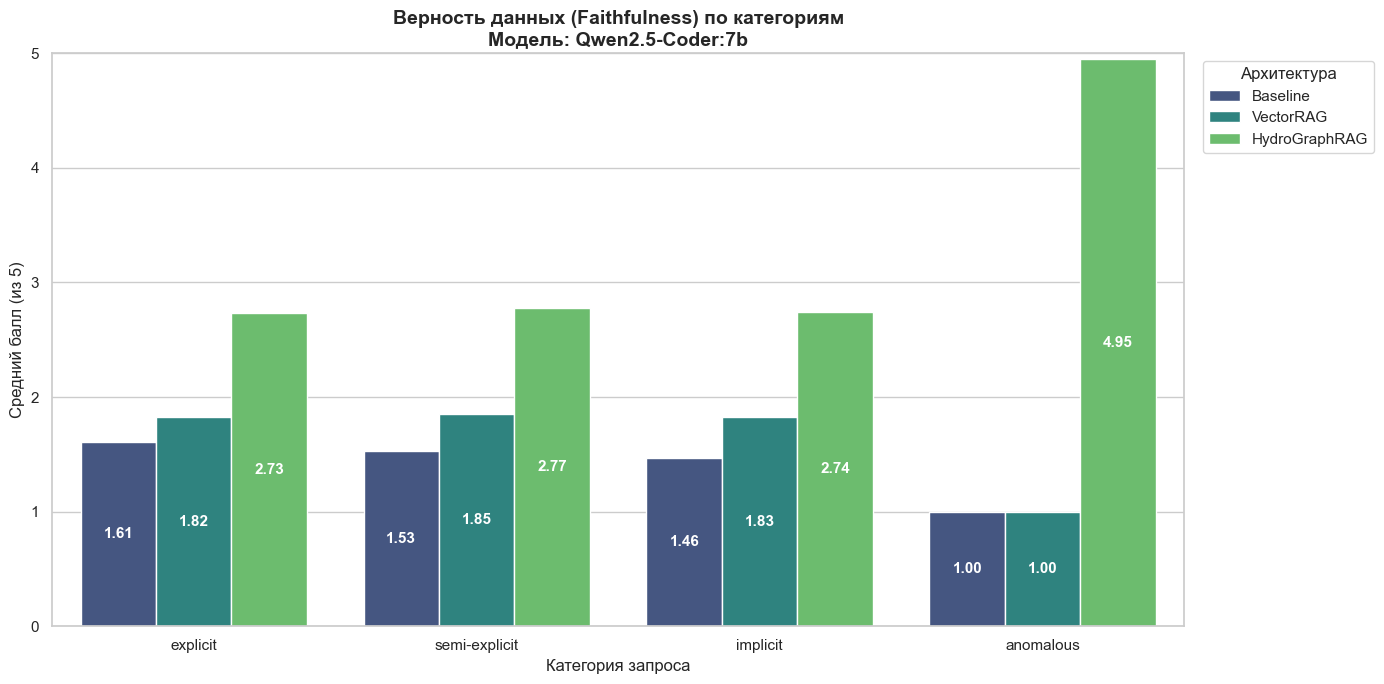

In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- ЗАГРУЗКА ---
file_path = r'C:\Users\Timur\Desktop\Diplomme\Code\evaluation\final_evaluation_results.json' # Укажи свой файл
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# --- ПАРСИНГ ---
records = []
architectures = ["Baseline", "VectorRAG", "GeoGraphRAG"]

for run in data:
    judge_model = run.get('model', 'unknown')
    for metric in run.get('metrics', []):
        query_id = metric.get('query_id')
        category = metric.get('category')
        
        for arch in architectures:
            if arch in metric:
                arch_data = metric[arch]
                dims = arch_data.get('dimension_breakdown', {})
                retrieval = arch_data.get('retrieval', {})
                
                record = {
                    'Model': judge_model,
                    'Category': category,
                    'Architecture': arch,
                    'Latency_sec': arch_data.get('latency'),
                    'Syntax_Valid': int(arch_data.get('syntax', False)),
                    'Exec_Valid': int(arch_data.get('exec', False)),
                    'Semantic_Score': arch_data.get('semantic_score'),
                    'Structural_Score': arch_data.get('structural_score'),
                    'Faithfulness_Score': arch_data.get('faithfulness_score'),
                    'Dim_Spatial': dims.get('spatial'),
                    'Dim_Temporal': dims.get('temporal'),
                    'Dim_Logic': dims.get('logic'),
                    'Triples_Count': arch_data.get('triples'),
                    'TDR': retrieval.get('tdr'),
                    'EER': retrieval.get('eer')
                }
                records.append(record)

df = pd.DataFrame(records)

# --- 1. ОЧИСТКА И ПЕРЕИМЕНОВАНИЕ ДАННЫХ ---
df['Category'] = df['Category'].replace('anomalulus', 'anomalous')
df['Architecture'] = df['Architecture'].replace('GeoGraphRAG', 'HydroGraphRAG')

# --- 2. ИЕРАРХИЧЕСКАЯ АГРЕГАЦИЯ И СОХРАНЕНИЕ ---
columns_to_mean = [
    'Syntax_Valid', 'Exec_Valid', 'Semantic_Score', 
    'Structural_Score', 'Faithfulness_Score', 
    'Dim_Spatial', 'Dim_Temporal', 'Dim_Logic'
]

# Группируем: Модель -> Категория -> Архитектура
summary_df = df.groupby(['Model', 'Category', 'Architecture'])[columns_to_mean].mean().round(3)

print("📊 ИТОГОВЫЕ МЕТРИКИ (Модель -> Категория -> Архитектура):")
display(summary_df)

# СОХРАНЕНИЕ ОБЩЕЙ ТАБЛИЦЫ
summary_df.to_excel("summary_metrics.xlsx")
print("💾 Таблица основных метрик сохранена как 'summary_metrics.xlsx'")


# --- 3. СПЕЦИФИЧНЫЕ МЕТРИКИ HYDROGRAPHRAG И СОХРАНЕНИЕ ---
print("\n🔗 МЕТРИКИ ГРАФА HYDROGRAPHRAG:")
hydro_stats = df[df['Architecture'] == 'HydroGraphRAG'].groupby(['Model', 'Category'])[['Triples_Count', 'TDR', 'EER']].mean().round(2)
display(hydro_stats)

# СОХРАНЕНИЕ ТАБЛИЦЫ МЕТРИК ГРАФА
hydro_stats.to_excel("hydrographrag_metrics.xlsx")
print("💾 Таблица метрик графа сохранена как 'hydrographrag_metrics.xlsx'")


# --- 4. НАУЧНАЯ ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=df, 
    x='Category', 
    y='Faithfulness_Score', 
    hue='Architecture', 
    errorbar=None, 
    palette='viridis'
)

plt.title('Верность данных (Faithfulness) по категориям\nМодель: Qwen2.5-Coder:7b', fontsize=14, fontweight='bold')
plt.ylabel('Средний балл (из 5)', fontsize=12)
plt.xlabel('Категория запроса', fontsize=12)
plt.ylim(0, 5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='center', color='white', fontweight='bold', fontsize=11)

plt.legend(title='Архитектура', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout() 

# Сохраним заодно и график в высоком качестве
plt.savefig("faithfulness_plot.png", dpi=300)
print("📸 График сохранен как 'faithfulness_plot.png'")

plt.show()

In [1]:
import json
import pandas as pd
from IPython.display import display

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================================
# Укажи правильный путь к твоему финальному JSON-файлу
FILE_PATH = r'C:\Users\Timur\Desktop\Diplomme\Code\evaluation\final_evaluation_results.json'

with open(FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

# ==========================================
# 2. ПАРСИНГ ВСЕХ МЕТРИК
# ==========================================
records = []
architectures = ["Baseline", "VectorRAG", "GeoGraphRAG"]

for run in data:
    model_name = run.get('model', 'unknown')
    
    for metric in run.get('metrics', []):
        category = metric.get('category', 'unknown').lower()
        
        # Авто-исправление опечаток в категориях
        if "anomal" in category:
            category = "anomalous"
            
        for arch in architectures:
            if arch in metric:
                arch_data = metric[arch]
                dims = arch_data.get('dimension_breakdown', {})
                retrieval = arch_data.get('retrieval', {})
                
                record = {
                    'LLM_Модель': model_name,
                    'Категория': category,
                    'Архитектура': 'HydroGraphRAG' if arch == 'GeoGraphRAG' else arch,
                    
                    # Метрики генерации (Stage 1)
                    'ESR (Успех кода)': int(arch_data.get('exec', False)),
                    'Syntax_Valid': int(arch_data.get('syntax', False)),
                    'Map_Rate': int(arch_data.get('has_map', False)),
                    'Latency (сек)': arch_data.get('latency'),
                    
                    # Метрики LLM-Судьи (Качество логики)
                    'Faithfulness': arch_data.get('faithfulness_score'),
                    'Semantic': arch_data.get('semantic_score'),
                    'Structural': arch_data.get('structural_score'),
                    'Dim_Spatial': dims.get('spatial'),
                    'Dim_Temporal': dims.get('temporal'),
                    'Dim_Logic': dims.get('logic'),
                    
                    # Графовые метрики (Stage 2 - только для HydroGraphRAG)
                    'Triples': arch_data.get('triples'),
                    'TDR (Полнота)': retrieval.get('tdr'),
                    'EER (Избыток)': retrieval.get('eer')
                }
                records.append(record)

df = pd.DataFrame(records)

# ==========================================
# 3. АГРЕГАЦИЯ И СОЗДАНИЕ МАСТЕР-ТАБЛИЦЫ
# ==========================================
metrics_to_aggregate = [
    'ESR (Успех кода)', 'Map_Rate', 'Latency (сек)', 
    'Faithfulness', 'Semantic', 'Structural', 
    'Dim_Spatial', 'Dim_Temporal', 'Dim_Logic', 
    'Triples', 'TDR (Полнота)', 'EER (Избыток)'
]

# Группируем по категории и архитектуре (усредняем по всем LLM моделям)
master_table = df.groupby(['Категория', 'Архитектура'])[metrics_to_aggregate].mean().round(3)

# Заменяем NaN (там, где метрик графа нет у Baseline и VectorRAG) на прочерк '-'
master_table = master_table.fillna('-')

# ==========================================
# 4. ВЫВОД И СОХРАНЕНИЕ
# ==========================================
print("🏆 ПОЛНАЯ СВОДНАЯ ТАБЛИЦА МЕТРИК (МАСТЕР-ТАБЛИЦА):")
display(master_table)

# Сохраняем в Excel для переноса в диплом
export_filename = 'master_metrics_table.xlsx'
master_table.to_excel(export_filename)
print(f"\n✅ Мастер-таблица успешно сохранена в файл: {export_filename}")

🏆 ПОЛНАЯ СВОДНАЯ ТАБЛИЦА МЕТРИК (МАСТЕР-ТАБЛИЦА):


ESR (Успех кода)  Map_Rate  Latency (сек)  \
Категория     Архитектура                                                
anomalous     Baseline                  0.354     0.356         19.243   
              HydroGraphRAG             0.004     0.004          3.455   
              VectorRAG                 0.421     0.423         16.748   
explicit      Baseline                  0.305     0.302         18.571   
              HydroGraphRAG             0.864     0.864         21.069   
              VectorRAG                 0.412     0.410         16.060   
implicit      Baseline                  0.216     0.224         20.495   
              HydroGraphRAG             0.846     0.846         24.132   
              VectorRAG                 0.395     0.397         17.398   
semi-explicit Baseline                  0.259     0.257         17.860   
              HydroGraphRAG             0.851     0.851         24.701   
              VectorRAG                 0.409     0.409         16.421   

                             Faithfulness  Semantic  Structural  Dim_Spatial  \
Категория     Архитектура                                                      
anomalous     Baseline              1.000     1.013       1.015        0.000   
              HydroGraphRAG         4.947     4.960       4.962        0.000   
              VectorRAG             1.000     1.013       1.015        0.000   
explicit      Baseline              1.610     3.295       2.905        2.590   
              HydroGraphRAG         2.729     3.862       4.590        3.724   
              VectorRAG             1.824     3.402       3.226        2.805   
implicit      Baseline              1.464     3.216       2.635        2.414   
              HydroGraphRAG         2.742     3.846       4.536        3.647   
              VectorRAG             1.825     3.395       3.175        2.763   
semi-explicit Baseline              1.529     3.249       2.766        2.494   
              HydroGraphRAG         2.772     3.838       4.552        3.608   
              VectorRAG             1.853     3.398       3.220        2.763   

                             Dim_Temporal  Dim_Logic Triples TDR (Полнота)  \
Категория     Архитектура                                                    
anomalous     Baseline              0.000      0.000       -             -   
              HydroGraphRAG         0.000      0.000   0.467         0.002   
              VectorRAG             0.000      0.000       -             -   
explicit      Baseline              1.019      1.412       -             -   
              HydroGraphRAG         2.140      2.555  40.148         0.645   
              VectorRAG             1.226      1.626       -             -   
implicit      Baseline              0.673      1.361       -             -   
              HydroGraphRAG         1.836      2.562  48.039          0.43   
              VectorRAG             1.000      1.695       -             -   
semi-explicit Baseline              0.766      1.324       -             -   
              HydroGraphRAG         1.786      2.419  83.919         0.659   
              VectorRAG             1.008      1.585       -             -   

                            EER (Избыток)  
Категория     Архитектура                  
anomalous     Baseline                  -  
              HydroGraphRAG         0.013  
              VectorRAG                 -  
explicit      Baseline                  -  
              HydroGraphRAG         3.104  
              VectorRAG                 -  
implicit      Baseline                  -  
              HydroGraphRAG         1.949  
              VectorRAG                 -  
semi-explicit Baseline                  -  
              HydroGraphRAG         2.991  
              VectorRAG                 -


✅ Мастер-таблица успешно сохранена в файл: master_metrics_table.xlsx


In [2]:
import json
import pandas as pd
import numpy as np
from IPython.display import display

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================================
RESULTS_PATH = r"C:\Users\Timur\Desktop\Diplomme\Code\evaluation\generation_results.json" # Укажи свой путь
GROUND_TRUTH_PATH = r"C:\Users\Timur\Desktop\Diplomme\Code\evaluation\ground_truth.json"   # Укажи свой путь

with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    results_data = json.load(f)
with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    gt_data = {str(item['id']): item for item in json.load(f)}

categories = ["explicit", "semi-explicit", "implicit", "anomalous"]
architectures = ["Baseline", "VectorRAG", "GeoGraphRAG"]

records = []

# ==========================================
# 2. СБОР И РАСЧЕТ ВСЕХ МЕТРИК
# ==========================================
for run in results_data:
    for metric in run.get("metrics", []):
        q_id = str(metric.get("query_id"))
        raw_cat = metric.get("category", "unknown").lower()
        cat = "anomalous" if "anomal" in raw_cat else raw_cat
        if cat not in categories: continue
            
        for arch in architectures:
            if arch in metric:
                arch_data = metric[arch]
                display_arch = 'HydroGraphRAG' if arch == 'GeoGraphRAG' else arch
                
                # Базовые метрики генерации и LLM-судьи
                record = {
                    'Категория': cat,
                    'Архитектура': display_arch,
                    'ESR': 1 if arch_data.get('exec') else 0,
                    'Map_Rate': 1 if arch_data.get('has_map') else 0,
                    'Latency': arch_data.get('latency', 0),
                    'Faithfulness': arch_data.get('faithfulness_score', np.nan),
                    'Semantic': arch_data.get('semantic_score', np.nan),
                    'Structural': arch_data.get('structural_score', np.nan)
                }
                
                # Специфичные графовые метрики (только для HydroGraphRAG и не аномальных)
                if arch == "GeoGraphRAG" and cat != "anomalous":
                    retrieval = arch_data.get("retrieval", {})
                    if retrieval and retrieval.get("status") != "no_ground_truth":
                        t_found = retrieval.get("targets_found", 0)
                        t_total = retrieval.get("retrieved_total", 0)
                        eer = retrieval.get("eer", 0.0)
                        
                        expected_count = len(gt_data.get(q_id, {}).get("expected_entities", []))
                        seed_nodes = t_total / (1 + eer) if (1 + eer) > 0 else t_total
                        
                        rec = t_found / expected_count if expected_count > 0 else 0.0
                        prec = min(1.0, t_found / seed_nodes if seed_nodes > 0 else 0.0)
                        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
                        
                        record['Triples'] = arch_data.get("triples", 0)
                        record['Recall_TDR'] = rec
                        record['Precision'] = prec
                        record['F1_Score'] = f1
                
                records.append(record)

df = pd.DataFrame(records)

# ==========================================
# 3. АГРЕГАЦИЯ В 3 ТАБЛИЦЫ (Усреднение по моделям)
# ==========================================

print("📊 ТАБЛИЦА 1: Эффективность генерации кода")
tab1 = df.groupby(['Категория', 'Архитектура'])[['ESR', 'Map_Rate', 'Latency']].mean().round(3)
display(tab1)
tab1.to_csv("diploma_table1_execution.csv")

print("\n🧠 ТАБЛИЦА 2: Оценка качества логики (LLM-Judge)")
tab2 = df.groupby(['Категория', 'Архитектура'])[['Faithfulness', 'Semantic', 'Structural']].mean().round(3)
display(tab2)
tab2.to_csv("diploma_table2_llm_judge.csv")

print("\n🔗 ТАБЛИЦА 3: Внутренние метрики графового извлечения (Только HydroGraphRAG)")
# Фильтруем только Hydro и убираем NaN значения (которые были у аномальных)
df_graph = df[df['Архитектура'] == 'HydroGraphRAG'].dropna(subset=['Recall_TDR'])
tab3 = df_graph.groupby(['Категория'])[['Precision', 'Recall_TDR', 'F1_Score', 'Triples']].mean().round(3)
display(tab3)
tab3.to_csv("diploma_table3_graph_metrics.csv")

print("\n✅ Все три таблицы успешно сохранены!")

📊 ТАБЛИЦА 1: Эффективность генерации кода


ESR  Map_Rate  Latency
Категория     Архитектура                            
anomalous     Baseline       0.354     0.356   19.243
              HydroGraphRAG  0.004     0.004    3.455
              VectorRAG      0.421     0.423   16.748
explicit      Baseline       0.305     0.302   18.571
              HydroGraphRAG  0.864     0.864   21.069
              VectorRAG      0.412     0.410   16.060
implicit      Baseline       0.216     0.224   20.495
              HydroGraphRAG  0.846     0.846   24.132
              VectorRAG      0.395     0.397   17.398
semi-explicit Baseline       0.259     0.257   17.860
              HydroGraphRAG  0.851     0.851   24.701
              VectorRAG      0.409     0.409   16.421


🧠 ТАБЛИЦА 2: Оценка качества логики (LLM-Judge)


Faithfulness  Semantic  Structural
Категория     Архитектура                                      
anomalous     Baseline                NaN       NaN         NaN
              HydroGraphRAG           NaN       NaN         NaN
              VectorRAG               NaN       NaN         NaN
explicit      Baseline                NaN       NaN         NaN
              HydroGraphRAG           NaN       NaN         NaN
              VectorRAG               NaN       NaN         NaN
implicit      Baseline                NaN       NaN         NaN
              HydroGraphRAG           NaN       NaN         NaN
              VectorRAG               NaN       NaN         NaN
semi-explicit Baseline                NaN       NaN         NaN
              HydroGraphRAG           NaN       NaN         NaN
              VectorRAG               NaN       NaN         NaN


🔗 ТАБЛИЦА 3: Внутренние метрики графового извлечения (Только HydroGraphRAG)


,Precision,Recall_TDR,F1_Score,Triples
Категория,,,,
explicit,0.645,0.645,0.645,40.148
implicit,0.457,0.430,0.439,48.039
semi-explicit,0.674,0.659,0.664,83.919



✅ Все три таблицы успешно сохранены!


In [5]:
import json
import pandas as pd
import numpy as np
from IPython.display import display

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================================
# Берем оценки из финального файла, а эталонные сущности из ground_truth
FINAL_EVAL_PATH = r"C:\Users\Timur\Desktop\Diplomme\Code\evaluation\final_evaluation_results.json"
GROUND_TRUTH_PATH = r"C:\Users\Timur\Desktop\Diplomme\Code\evaluation\ground_truth.json"   

with open(FINAL_EVAL_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    gt_data = {str(item['id']): item for item in json.load(f)}

categories = ["explicit", "semi-explicit", "implicit", "anomalous"]
architectures = ["Baseline", "VectorRAG", "GeoGraphRAG"]
records = []

# ==========================================
# 2. ПАРСИНГ ФИНАЛЬНЫХ МЕТРИК
# ==========================================
for run in data:
    model_name = run.get("model", "unknown")
    
    for metric in run.get("metrics", []):
        q_id = str(metric.get("query_id"))
        raw_cat = metric.get("category", "unknown").lower()
        cat = "anomalous" if "anomal" in raw_cat else raw_cat
        if cat not in categories: continue
            
        for arch in architectures:
            if arch in metric:
                arch_data = metric[arch]
                display_arch = 'HydroGraphRAG' if arch == 'GeoGraphRAG' else arch
                
                # Собираем данные (теперь Faithfulness точно будет!)
                record = {
                    'Модель LLM': model_name,
                    'Категория': cat,
                    'Архитектура': display_arch,
                    'ESR': 1 if arch_data.get('exec') else 0,
                    'Map_Rate': 1 if arch_data.get('has_map', False) else 0, # Защита от KeyError
                    'Latency': arch_data.get('latency', 0),
                    'Faithfulness': arch_data.get('faithfulness_score', np.nan),
                    'Semantic': arch_data.get('semantic_score', np.nan),
                    'Structural': arch_data.get('structural_score', np.nan)
                }
                
                # Расчет Precision/Recall графа (только для HydroGraphRAG и не аномальных)
                if arch == "GeoGraphRAG" and cat != "anomalous":
                    retrieval = arch_data.get("retrieval", {})
                    if retrieval and retrieval.get("status") != "no_ground_truth":
                        t_found = retrieval.get("targets_found", 0)
                        t_total = retrieval.get("retrieved_total", 0)
                        eer = retrieval.get("eer", 0.0)
                        
                        expected_count = len(gt_data.get(q_id, {}).get("expected_entities", []))
                        # Восстанавливаем кол-во seed nodes
                        seed_nodes = t_total / (1 + eer) if (1 + eer) > 0 else t_total
                        
                        rec = t_found / expected_count if expected_count > 0 else 0.0
                        prec = min(1.0, t_found / seed_nodes if seed_nodes > 0 else 0.0)
                        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
                        
                        record['Triples'] = arch_data.get("triples", 0)
                        record['Recall_TDR'] = rec
                        record['Precision'] = prec
                        record['F1_Score'] = f1
                
                records.append(record)

df = pd.DataFrame(records)

# ==========================================
# 3. ГЕНЕРАЦИЯ 3-Х ТАБЛИЦ ДЛЯ ДИПЛОМА
# ==========================================

print("📊 ТАБЛИЦА 1: Эффективность генерации кода (Усреднено по моделям)")
tab1 = df.groupby(['Категория', 'Архитектура'])[['ESR', 'Map_Rate', 'Latency']].mean().round(3)
display(tab1)
tab1.to_csv("diploma_table1_execution.csv")

print("\n🧠 ТАБЛИЦА 2: Оценка качества логики LLM-Judge (Усреднено по моделям)")
tab2 = df.groupby(['Категория', 'Архитектура'])[['Faithfulness', 'Semantic', 'Structural']].mean().round(3)
display(tab2)
tab2.to_csv("diploma_table2_llm_judge.csv")

print("\n🔗 ТАБЛИЦА 3: Внутренние метрики графа ПО КАЖДОЙ МОДЕЛИ")
# Фильтруем только Hydro и убираем строки без TDR (аномальные запросы)
df_graph = df[df['Архитектура'] == 'HydroGraphRAG'].dropna(subset=['Recall_TDR'])
tab3_detailed = df_graph.groupby(['Модель LLM', 'Категория'])[['Precision', 'Recall_TDR', 'F1_Score', 'Triples']].mean().round(3)
display(tab3_detailed)
tab3_detailed.to_csv("diploma_table3_models_graph.csv")

print("\n✅ Успех! NaN-ы побеждены, все три таблицы сохранены в CSV.")

📊 ТАБЛИЦА 1: Эффективность генерации кода (Усреднено по моделям)


ESR  Map_Rate  Latency
Категория     Архитектура                            
anomalous     Baseline       0.354     0.356   19.243
              HydroGraphRAG  0.004     0.004    3.455
              VectorRAG      0.421     0.423   16.748
explicit      Baseline       0.305     0.302   18.571
              HydroGraphRAG  0.864     0.864   21.069
              VectorRAG      0.412     0.410   16.060
implicit      Baseline       0.216     0.224   20.495
              HydroGraphRAG  0.846     0.846   24.132
              VectorRAG      0.395     0.397   17.398
semi-explicit Baseline       0.259     0.257   17.860
              HydroGraphRAG  0.851     0.851   24.701
              VectorRAG      0.409     0.409   16.421


🧠 ТАБЛИЦА 2: Оценка качества логики LLM-Judge (Усреднено по моделям)


Faithfulness  Semantic  Structural
Категория     Архитектура                                      
anomalous     Baseline              1.000     1.013       1.015
              HydroGraphRAG         4.947     4.960       4.962
              VectorRAG             1.000     1.013       1.015
explicit      Baseline              1.610     3.295       2.905
              HydroGraphRAG         2.729     3.862       4.590
              VectorRAG             1.824     3.402       3.226
implicit      Baseline              1.464     3.216       2.635
              HydroGraphRAG         2.742     3.846       4.536
              VectorRAG             1.825     3.395       3.175
semi-explicit Baseline              1.529     3.249       2.766
              HydroGraphRAG         2.772     3.838       4.552
              VectorRAG             1.853     3.398       3.220


🔗 ТАБЛИЦА 3: Внутренние метрики графа ПО КАЖДОЙ МОДЕЛИ


Precision  Recall_TDR  F1_Score  Triples
Модель LLM        Категория                                              
codestral         explicit           0.867       0.867     0.867   55.683
                  implicit           0.658       0.605     0.623   64.474
                  semi-explicit      0.865       0.831     0.842  108.311
gemma2:27b        explicit           0.783       0.783     0.783   49.183
                  implicit           0.605       0.572     0.583   66.842
                  semi-explicit      0.851       0.838     0.842  105.014
gemma4:31b        explicit           0.800       0.800     0.800   48.950
                  implicit           0.553       0.507     0.522   55.132
                  semi-explicit      0.878       0.842     0.854  105.959
llama3.1:8b       explicit           0.017       0.017     0.017    0.900
                  implicit           0.000       0.000     0.000    0.000
                  semi-explicit      0.000       0.000     0.000    0.000
mistral-nemo      explicit           0.500       0.500     0.500   33.517
                  implicit           0.474       0.454     0.461   49.303
                  semi-explicit      0.554       0.547     0.550   74.676
qwen2.5-coder:32b explicit           0.767       0.767     0.767   44.833
                  implicit           0.487       0.447     0.461   52.105
                  semi-explicit      0.770       0.757     0.761   92.162
qwen2.5-coder:7b  explicit           0.783       0.783     0.783   47.967
                  implicit           0.421       0.421     0.421   48.421
                  semi-explicit      0.797       0.797     0.797  101.311


✅ Успех! NaN-ы побеждены, все три таблицы сохранены в CSV.


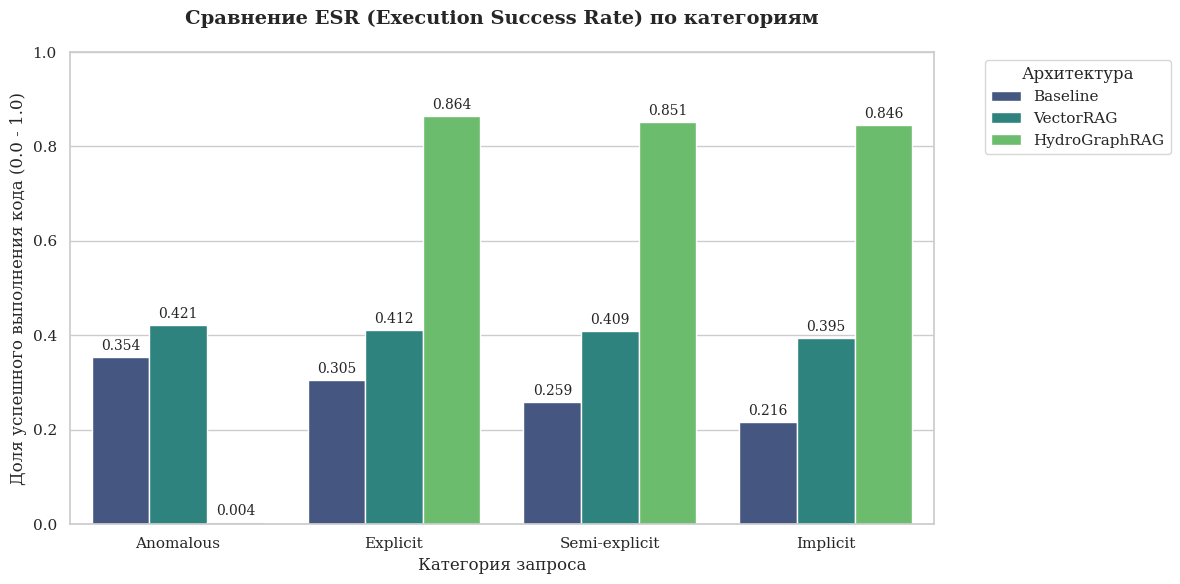

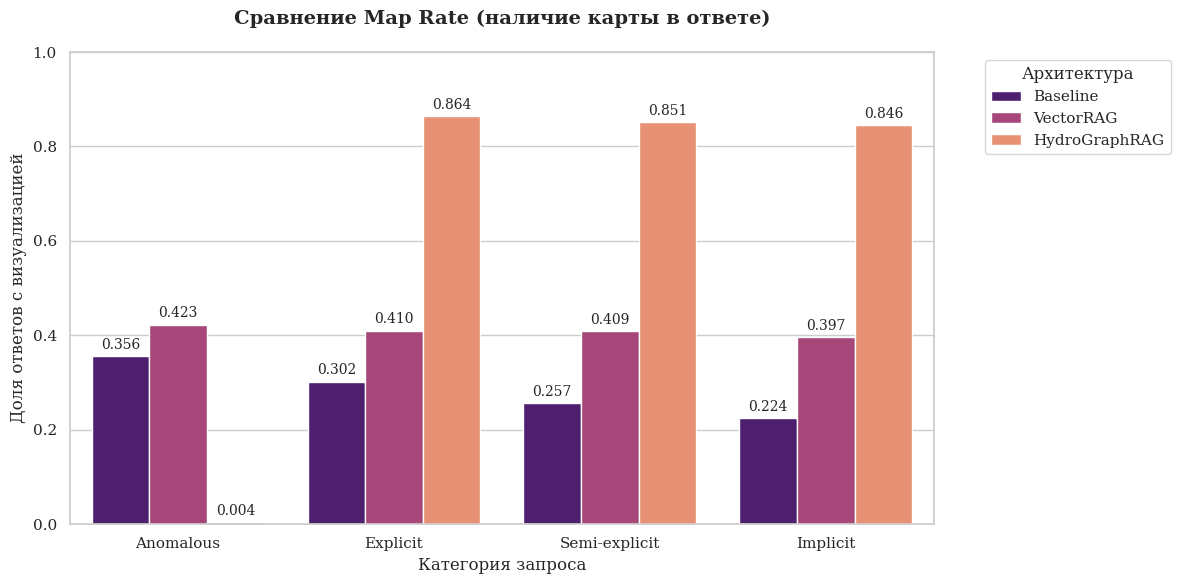

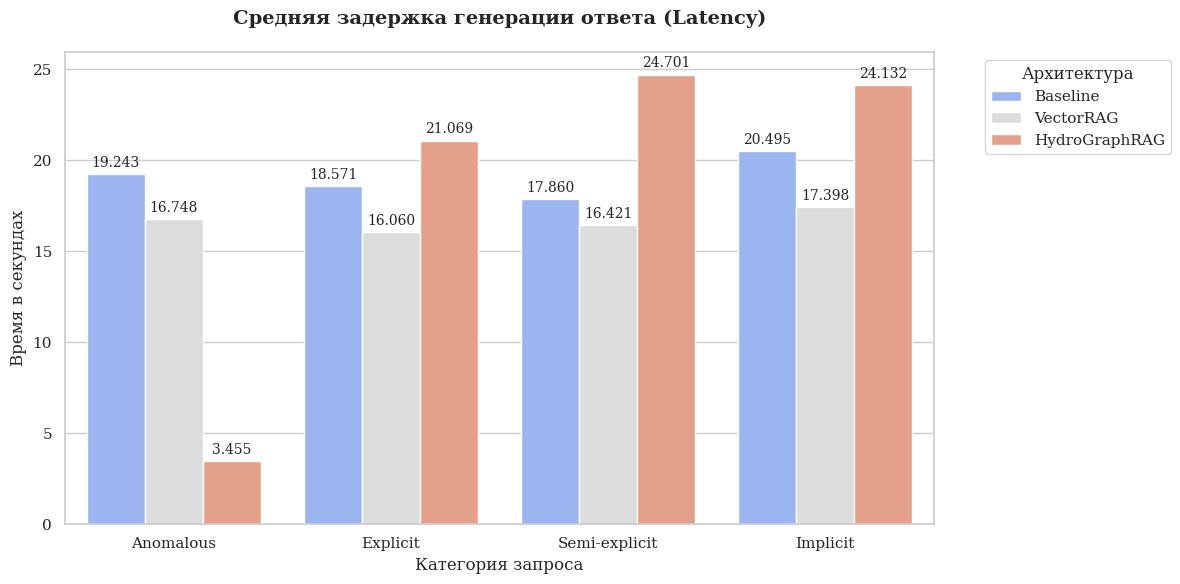

✅ Графики для Таблицы 1 успешно созданы и сохранены!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. ПОДГОТОВКА ДАННЫХ (на основе твоей Таблицы 1)
data = {
    'Category': [
        'Anomalous', 'Anomalous', 'Anomalous',
        'Explicit', 'Explicit', 'Explicit',
        'Semi-explicit', 'Semi-explicit', 'Semi-explicit',
        'Implicit', 'Implicit', 'Implicit'
    ],
    'Architecture': [
        'Baseline', 'VectorRAG', 'HydroGraphRAG',
        'Baseline', 'VectorRAG', 'HydroGraphRAG',
        'Baseline', 'VectorRAG', 'HydroGraphRAG',
        'Baseline', 'VectorRAG', 'HydroGraphRAG'
    ],
    'ESR': [0.354, 0.421, 0.004, 0.305, 0.412, 0.864, 0.259, 0.409, 0.851, 0.216, 0.395, 0.846],
    'Map_Rate': [0.356, 0.423, 0.004, 0.302, 0.410, 0.864, 0.257, 0.409, 0.851, 0.224, 0.397, 0.846],
    'Latency': [19.243, 16.748, 3.455, 18.571, 16.060, 21.069, 17.860, 16.421, 24.701, 20.495, 17.398, 24.132]
}

df = pd.DataFrame(data)

# Настройка стиля для научной публикации
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Функция для создания однотипных графиков
def create_plot(metric, title, ylabel, filename, color_palette="viridis", ylim=None):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Category', y=metric, hue='Architecture', data=df, palette=color_palette)
    
    plt.title(title, fontweight='bold', pad=20)
    plt.ylabel(ylabel)
    plt.xlabel('Категория запроса')
    plt.legend(title='Архитектура', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if ylim:
        plt.ylim(0, ylim)
    
    # Добавляем значения над столбцами
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# --- ГЕНЕРАЦИЯ 3-Х ГРАФИКОВ ---

# 1. ESR (Надежность исполнения кода)
create_plot('ESR', 'Сравнение ESR (Execution Success Rate) по категориям', 
            'Доля успешного выполнения кода (0.0 - 1.0)', 'chart_table1_esr.png', ylim=1.0)

# 2. Map Rate (Генерация визуализаций)
create_plot('Map_Rate', 'Сравнение Map Rate (наличие карты в ответе)', 
            'Доля ответов с визуализацией', 'chart_table1_maprate.png', color_palette="magma", ylim=1.0)

# 3. Latency (Скорость ответа)
create_plot('Latency', 'Средняя задержка генерации ответа (Latency)', 
            'Время в секундах', 'chart_table1_latency.png', color_palette="coolwarm")

print("✅ Графики для Таблицы 1 успешно созданы и сохранены!")

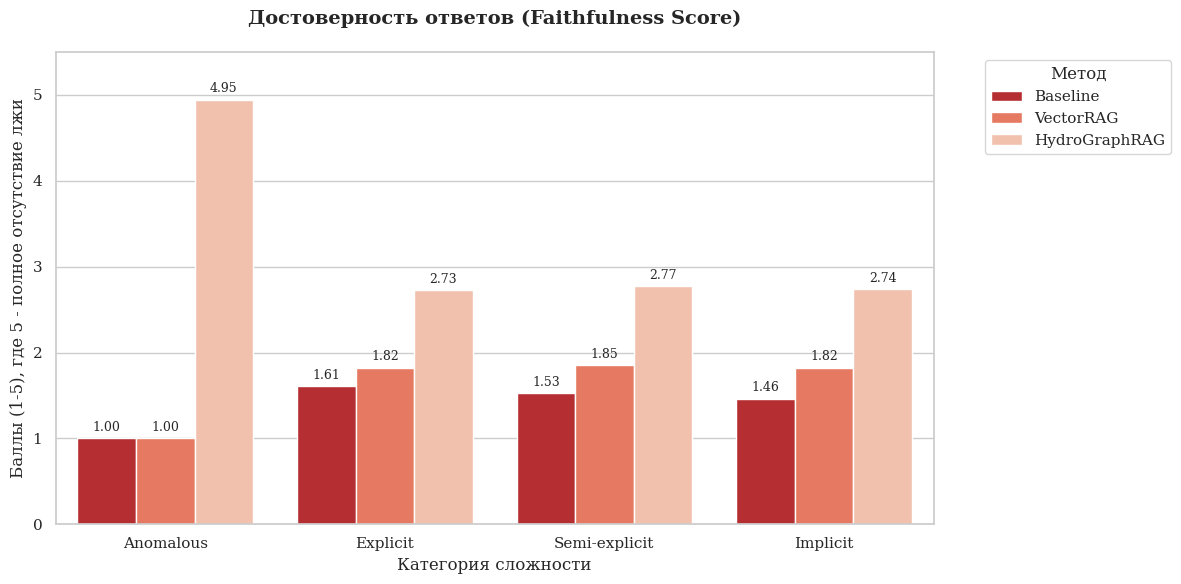

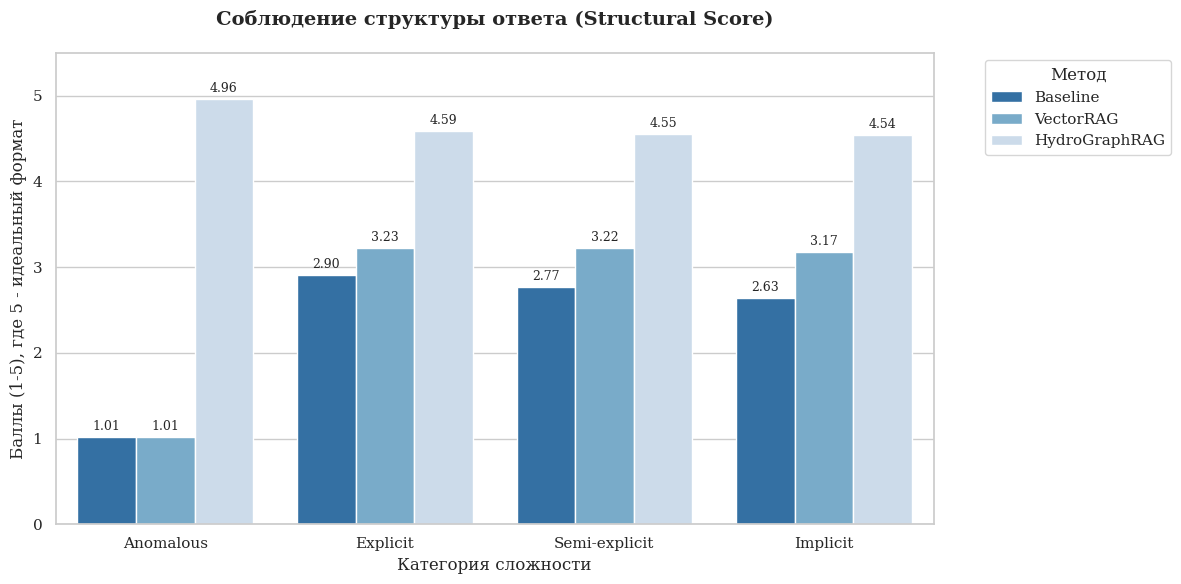

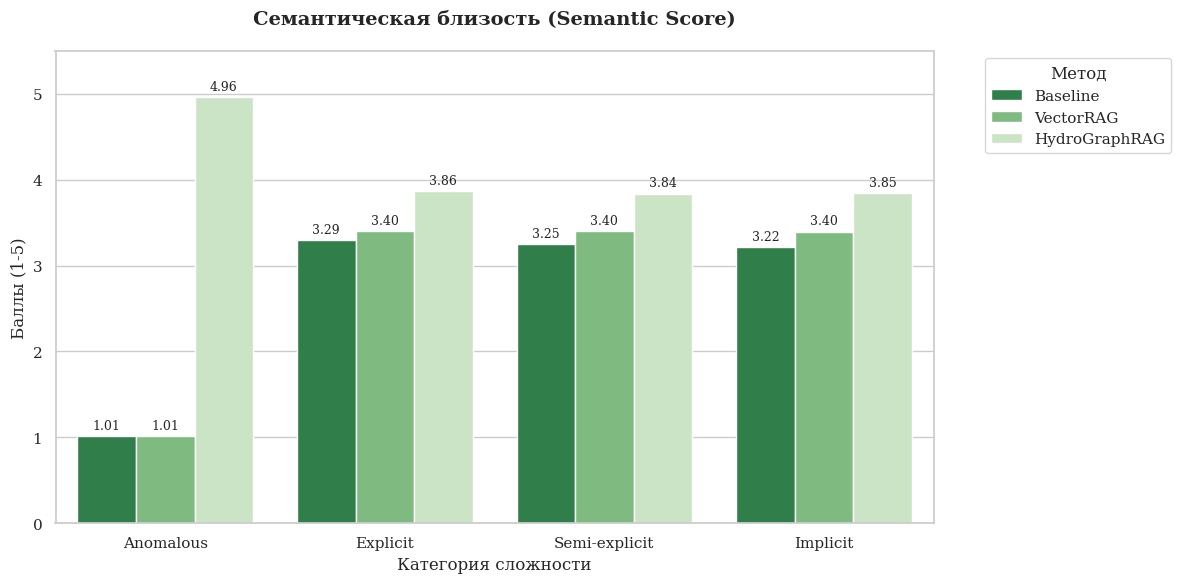

✅ Графики для Таблицы 2 готовы. Теперь у тебя есть визуальное доказательство, что твоя система не врет!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. ПОДГОТОВКА ДАННЫХ (на основе твоей Таблицы 2)
data_judge = {
    'Category': [
        'Anomalous', 'Anomalous', 'Anomalous',
        'Explicit', 'Explicit', 'Explicit',
        'Semi-explicit', 'Semi-explicit', 'Semi-explicit',
        'Implicit', 'Implicit', 'Implicit'
    ],
    'Architecture': [
        'Baseline', 'VectorRAG', 'HydroGraphRAG',
        'Baseline', 'VectorRAG', 'HydroGraphRAG',
        'Baseline', 'VectorRAG', 'HydroGraphRAG',
        'Baseline', 'VectorRAG', 'HydroGraphRAG'
    ],
    'Faithfulness': [1.000, 1.000, 4.947, 1.610, 1.824, 2.729, 1.529, 1.853, 2.772, 1.464, 1.825, 2.742],
    'Semantic': [1.013, 1.013, 4.960, 3.295, 3.402, 3.862, 3.249, 3.398, 3.838, 3.216, 3.395, 3.846],
    'Structural': [1.015, 1.015, 4.962, 2.905, 3.226, 4.590, 2.766, 3.220, 4.552, 2.635, 3.175, 4.536]
}

df_judge = pd.DataFrame(data_judge)

# Настройка стиля (как в предыдущем сете)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

def create_judge_plot(metric, title, ylabel, filename, color_palette="YlGnBu"):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Category', y=metric, hue='Architecture', data=df_judge, palette=color_palette)
    
    plt.title(title, fontweight='bold', pad=20)
    plt.ylabel(ylabel)
    plt.xlabel('Категория сложности')
    plt.ylim(0, 5.5) # Все оценки судьи по шкале 1-5
    plt.legend(title='Метод', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Добавляем цифры над столбцами
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# --- ГЕНЕРАЦИЯ ГРАФИКОВ ---

# 1. Faithfulness (Отсутствие галлюцинаций - КИЛЛЕР-ФИЧА)
create_judge_plot('Faithfulness', 'Достоверность ответов (Faithfulness Score)', 
                  'Баллы (1-5), где 5 - полное отсутствие лжи', 'chart_judge_faithfulness.png', color_palette="Reds_r")

# 2. Structural (Следование формату кода)
create_judge_plot('Structural', 'Соблюдение структуры ответа (Structural Score)', 
                  'Баллы (1-5), где 5 - идеальный формат', 'chart_judge_structural.png', color_palette="Blues_r")

# 3. Semantic (Соответствие смыслу запроса)
create_judge_plot('Semantic', 'Семантическая близость (Semantic Score)', 
                  'Баллы (1-5)', 'chart_judge_semantic.png', color_palette="Greens_r")

print("✅ Графики для Таблицы 2 готовы. Теперь у тебя есть визуальное доказательство, что твоя система не врет!")

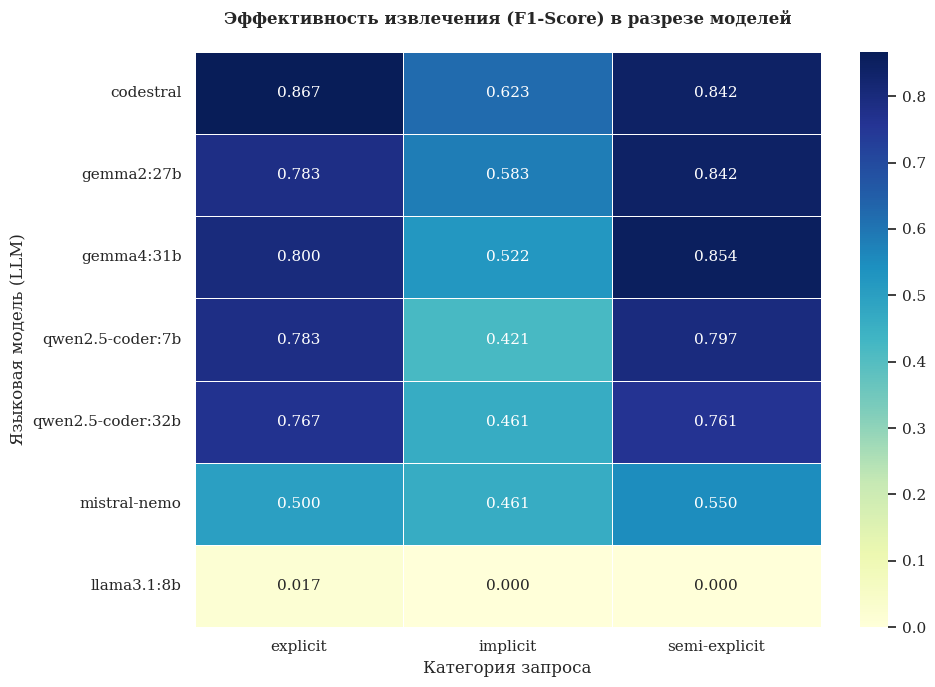

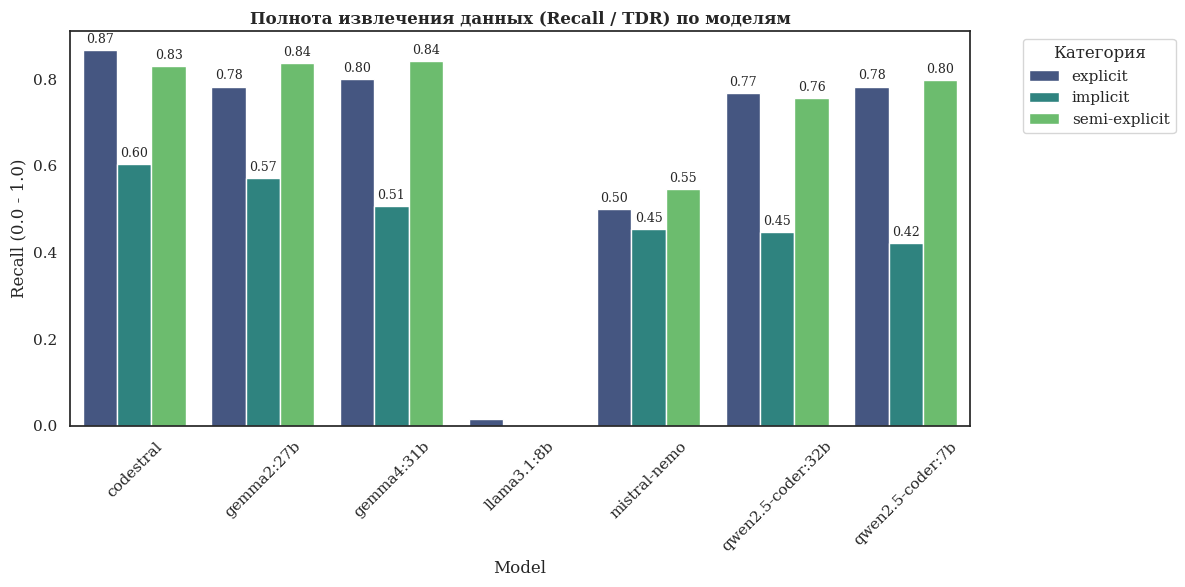

✅ Тепловая карта и лидерборд моделей готовы!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. ДАННЫЕ (из твоего вывода Таблицы 3)
raw_data = [
    ['codestral', 'explicit', 0.867, 0.867, 0.867, 55.683],
    ['codestral', 'implicit', 0.658, 0.605, 0.623, 64.474],
    ['codestral', 'semi-explicit', 0.865, 0.831, 0.842, 108.311],
    ['gemma2:27b', 'explicit', 0.783, 0.783, 0.783, 49.183],
    ['gemma2:27b', 'implicit', 0.605, 0.572, 0.583, 66.842],
    ['gemma2:27b', 'semi-explicit', 0.851, 0.838, 0.842, 105.014],
    ['gemma4:31b', 'explicit', 0.800, 0.800, 0.800, 48.950],
    ['gemma4:31b', 'implicit', 0.553, 0.507, 0.522, 55.132],
    ['gemma4:31b', 'semi-explicit', 0.878, 0.842, 0.854, 105.959],
    ['llama3.1:8b', 'explicit', 0.017, 0.017, 0.017, 0.900],
    ['llama3.1:8b', 'implicit', 0.000, 0.000, 0.000, 0.000],
    ['llama3.1:8b', 'semi-explicit', 0.000, 0.000, 0.000, 0.000],
    ['mistral-nemo', 'explicit', 0.500, 0.500, 0.500, 33.517],
    ['mistral-nemo', 'implicit', 0.474, 0.454, 0.461, 49.303],
    ['mistral-nemo', 'semi-explicit', 0.554, 0.547, 0.550, 74.676],
    ['qwen2.5-coder:32b', 'explicit', 0.767, 0.767, 0.767, 44.833],
    ['qwen2.5-coder:32b', 'implicit', 0.487, 0.447, 0.461, 52.105],
    ['qwen2.5-coder:32b', 'semi-explicit', 0.770, 0.757, 0.761, 92.162],
    ['qwen2.5-coder:7b', 'explicit', 0.783, 0.783, 0.783, 47.967],
    ['qwen2.5-coder:7b', 'implicit', 0.421, 0.421, 0.421, 48.421],
    ['qwen2.5-coder:7b', 'semi-explicit', 0.797, 0.797, 0.797, 101.311],
]

df_models = pd.DataFrame(raw_data, columns=['Model', 'Category', 'Precision', 'Recall', 'F1', 'Triples'])

# Настройка стиля
sns.set_theme(style="white")
plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

# --- ГРАФИК 1: HEATMAP (F1-Score) ---
plt.figure(figsize=(10, 7))
pivot_f1 = df_models.pivot(index="Model", columns="Category", values="F1")
# Сортируем модели по среднему F1, чтобы лидеры были сверху
pivot_f1 = pivot_f1.reindex(pivot_f1.mean(axis=1).sort_values(ascending=False).index)

sns.heatmap(pivot_f1, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5)
plt.title('Эффективность извлечения (F1-Score) в разрезе моделей', fontweight='bold', pad=20)
plt.xlabel('Категория запроса')
plt.ylabel('Языковая модель (LLM)')
plt.tight_layout()
plt.savefig('chart_models_heatmap_f1.png', dpi=300)
plt.show()

# --- ГРАФИК 2: RECALL / TDR (Grouped Bar) ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Recall', hue='Category', data=df_models, palette='viridis')
plt.title('Полнота извлечения данных (Recall / TDR) по моделям', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Recall (0.0 - 1.0)')
plt.legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')

# Добавляем значения (кроме нулей, чтобы не мусорить)
for container in ax.containers:
    labels = [f'{v:.2f}' if v > 0.05 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('chart_models_recall_bars.png', dpi=300)
plt.show()

print("✅ Тепловая карта и лидерборд моделей готовы!")

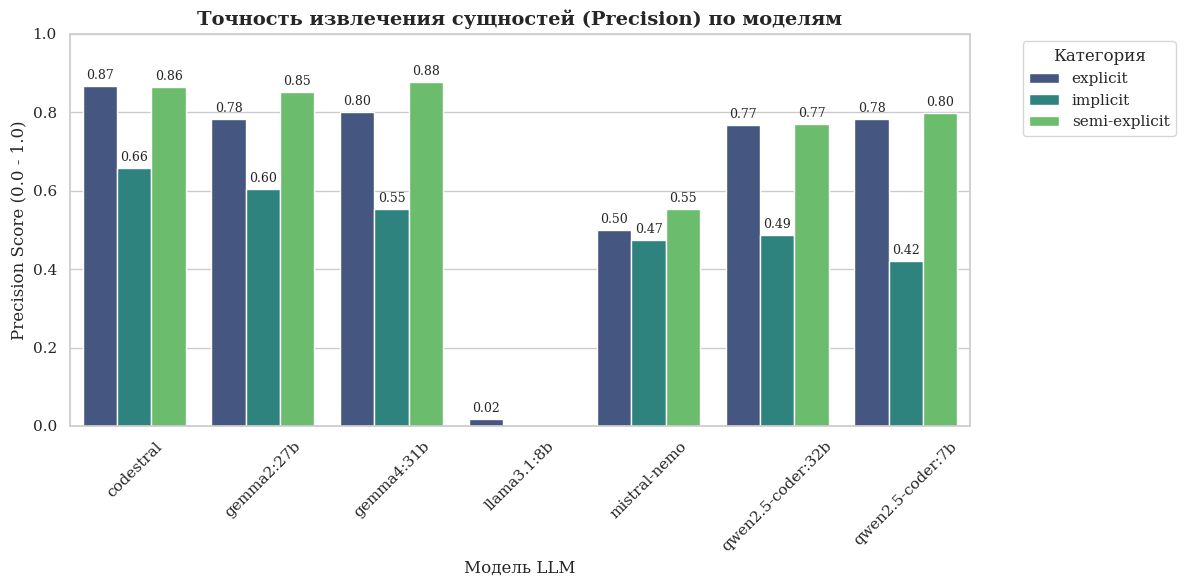

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Данные Precision из твоего вывода
precision_data = [
    ['codestral', 'explicit', 0.867], ['codestral', 'implicit', 0.658], ['codestral', 'semi-explicit', 0.865],
    ['gemma2:27b', 'explicit', 0.783], ['gemma2:27b', 'implicit', 0.605], ['gemma2:27b', 'semi-explicit', 0.851],
    ['gemma4:31b', 'explicit', 0.800], ['gemma4:31b', 'implicit', 0.553], ['gemma4:31b', 'semi-explicit', 0.878],
    ['llama3.1:8b', 'explicit', 0.017], ['llama3.1:8b', 'implicit', 0.000], ['llama3.1:8b', 'semi-explicit', 0.000],
    ['mistral-nemo', 'explicit', 0.500], ['mistral-nemo', 'implicit', 0.474], ['mistral-nemo', 'semi-explicit', 0.554],
    ['qwen2.5-coder:32b', 'explicit', 0.767], ['qwen2.5-coder:32b', 'implicit', 0.487], ['qwen2.5-coder:32b', 'semi-explicit', 0.770],
    ['qwen2.5-coder:7b', 'explicit', 0.783], ['qwen2.5-coder:7b', 'implicit', 0.421], ['qwen2.5-coder:7b', 'semi-explicit', 0.797]
]

df_prec = pd.DataFrame(precision_data, columns=['Model', 'Category', 'Precision'])

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

plt.figure(figsize=(12, 6))
# Используем палитру 'viridis' для преемственности с графиком Recall
ax = sns.barplot(x='Model', y='Precision', hue='Category', data=df_prec, palette='viridis')

plt.title('Точность извлечения сущностей (Precision) по моделям', fontweight='bold', fontsize=14)
plt.ylabel('Precision Score (0.0 - 1.0)')
plt.xlabel('Модель LLM')
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')

# Добавляем значения над столбцами
for container in ax.containers:
    labels = [f'{v:.2f}' if v > 0.01 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('chart_models_precision.png', dpi=300)
plt.show()

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. НАСТРОЙКИ СТИЛЯ ДЛЯ ЖУРНАЛОВ IEEE
# ==========================================
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=3.6) # Масштаб выкручен еще на 30%

plt.rcParams.update({
    'font.family': 'serif',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.dpi': 300,        
    'pdf.fonttype': 42,       
    'ps.fonttype': 42
})

# ==========================================
# 2. ЗАГРУЗКА И ОБРАБОТКА ДАННЫХ
# ==========================================
FINAL_EVAL_PATH = "final_evaluation_results.json"
GROUND_TRUTH_PATH = "ground_truth.json"

print("⏳ Загрузка данных...")
with open(FINAL_EVAL_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    gt_data = {str(item['id']): item for item in json.load(f)}

categories = ["explicit", "semi-explicit", "implicit", "anomalous"]
architectures = ["Baseline", "VectorRAG", "GeoGraphRAG"]
records = []

for run in data:
    model_name = run.get("model", "unknown").capitalize()
    for metric in run.get("metrics",[]):
        q_id = str(metric.get("query_id"))
        raw_cat = metric.get("category", "unknown").lower()
        cat = "Anomalous" if "anomal" in raw_cat else raw_cat.capitalize()
        
        for arch in architectures:
            if arch in metric:
                arch_data = metric[arch]
                display_arch = 'HydroGraphRAG' if arch == 'GeoGraphRAG' else arch
                
                record = {
                    'Model': model_name,
                    'Category': cat,
                    'Architecture': display_arch,
                    'ESR': 1 if arch_data.get('exec') else 0,
                    'Map_Rate': 1 if arch_data.get('has_map') else 0,
                    'Latency': arch_data.get('latency', np.nan),
                    'Faithfulness': arch_data.get('faithfulness_score', np.nan),
                    'Semantic': arch_data.get('semantic_score', np.nan),
                    'Structural': arch_data.get('structural_score', np.nan)
                }
                
                if arch == "GeoGraphRAG" and cat != "Anomalous":
                    retrieval = arch_data.get("retrieval", {})
                    if retrieval and retrieval.get("status") != "no_ground_truth":
                        t_found = retrieval.get("targets_found", 0)
                        t_total = retrieval.get("retrieved_total", 0)
                        eer = retrieval.get("eer", 0.0)
                        
                        expected_count = len(gt_data.get(q_id, {}).get("expected_entities",[]))
                        seed_nodes = t_total / (1 + eer) if (1 + eer) > 0 else t_total
                        
                        rec = t_found / expected_count if expected_count > 0 else 0.0
                        prec = min(1.0, t_found / seed_nodes if seed_nodes > 0 else 0.0)
                        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
                        
                        record['Precision'] = prec
                        record['Recall_TDR'] = rec
                        record['F1_Score'] = f1
                        record['Triples'] = arch_data.get("triples", 0)
                else:
                    record['Precision'] = np.nan
                    record['Recall_TDR'] = np.nan
                    record['F1_Score'] = np.nan
                    record['Triples'] = np.nan
                
                records.append(record)

df = pd.DataFrame(records)

cat_order_all = ["Explicit", "Semi-explicit", "Implicit", "Anomalous"]
cat_order_valid = ["Explicit", "Semi-explicit", "Implicit"]

# ==========================================
# 3. ФУНКЦИИ ПОСТРОЕНИЯ (ХОЛСТ x1.5, ШРИФТЫ +30%)
# ==========================================

# ==========================================
# 3. ФУНКЦИИ ПОСТРОЕНИЯ (ФИКС НАЛОЖЕНИЯ ТИТУЛА)
# ==========================================

def plot_general_metric(metric_col, title_prefix, ylabel, prefix_filename, ylim, palette):
    for cat in cat_order_all:
        df_cat = df[df['Category'] == cat].groupby(['Model', 'Architecture'])[metric_col].mean().reset_index()
        
        if df_cat[metric_col].isnull().all():
            continue
            
        plt.figure(figsize=(18, 12)) 
        
        ax = sns.barplot(data=df_cat, x='Model', y=metric_col, hue='Architecture', palette=palette, width=0.85)
        
        # pad=140 сильно откидывает заголовок наверх
        plt.title(f'{title_prefix} - {cat} Queries', pad=140, fontsize=47) 
        plt.ylabel(ylabel, fontsize=47) 
        plt.xlabel('') 
        plt.xticks(rotation=40, ha='right', fontsize=40) 
        plt.yticks(fontsize=40) 
        
        current_ylim = ylim if ylim is not None else df_cat[metric_col].max() * 1.6
        plt.ylim(0, current_ylim)
        
        # 1.02 опускает легенду ближе к графику (подальше от заголовка)
        plt.legend(title='', bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=3, frameon=False, fontsize=40) 
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=10, fontsize=36, rotation=90) 
            
        plt.savefig(f'{prefix_filename}_{cat.replace("-", "")}.pdf', format='pdf', bbox_inches='tight')
        plt.close()

def plot_graph_metric(metric_col, title_prefix, ylabel, prefix_filename, color_hex):
    for cat in cat_order_valid:
        df_cat = df[(df['Category'] == cat) & (df['Architecture'] == 'HydroGraphRAG')].groupby('Model')[metric_col].mean().reset_index()
        
        plt.figure(figsize=(12, 12))
        ax = sns.barplot(data=df_cat, x='Model', y=metric_col, color=color_hex, width=0.7)
        
        # Тут легенды нет, pad=90 хватит с головой
        plt.title(f'{title_prefix} - {cat} Queries', pad=90, fontsize=44) 
        plt.ylabel(ylabel, fontsize=44) 
        plt.xlabel('')
        plt.xticks(rotation=45, ha='right', fontsize=36) 
        plt.yticks(fontsize=36) 
        plt.ylim(0, 1.45)
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=8, fontsize=36) 
            
        plt.savefig(f'{prefix_filename}_{cat.replace("-", "")}.pdf', format='pdf', bbox_inches='tight')
        plt.close()

def plot_gap_metric():
    for cat in cat_order_valid:
        df_cat = df[(df['Category'] == cat) & (df['Architecture'] == 'HydroGraphRAG')].groupby('Model')[['F1_Score', 'ESR']].mean().reset_index()
        
        x = np.arange(len(df_cat['Model']))
        width = 0.42 
        
        fig, ax = plt.subplots(figsize=(18, 12))
        rects1 = ax.bar(x - width/2, df_cat['F1_Score'], width, label='Graph Retrieval (F1)', color='#2ca02c')
        rects2 = ax.bar(x + width/2, df_cat['ESR'], width, label='Code Execution (ESR)', color='#1f77b4')
        
        # pad=140
        ax.set_title(f'Cognitive-Syntactic Gap - {cat} Queries', pad=140, fontsize=47) 
        ax.set_ylabel('Score (0.0 to 1.0)', fontsize=47) 
        ax.set_xlabel('')
        ax.set_xticks(x)
        ax.set_xticklabels(df_cat['Model'], rotation=40, ha='right', fontsize=40) 
        ax.tick_params(axis='y', labelsize=40) 
        ax.set_ylim(0, 1.6)
        
        # 1.02
        ax.legend(bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=2, frameon=False, fontsize=40) 
        
        ax.bar_label(rects1, fmt='%.2f', padding=10, fontsize=36, rotation=90) 
        ax.bar_label(rects2, fmt='%.2f', padding=10, fontsize=36, rotation=90) 
        
        filename = f'M10_CognitiveGap_{cat.replace("-", "")}.pdf'
        plt.savefig(filename, format='pdf', bbox_inches='tight')
        plt.close()

print("🎨 Генерация графиков (Холст x1.5, шрифты +30%, отступы увеличены)...")
plot_general_metric('ESR', 'Execution Success Rate', 'Rate (0.0 - 1.0)', 'M1_ESR', 1.45, 'viridis')
plot_general_metric('Map_Rate', 'Map Generation Rate', 'Rate (0.0 - 1.0)', 'M2_MapRate', 1.45, 'magma')
plot_general_metric('Latency', 'Response Latency', 'Seconds', 'M3_Latency', None, 'cubehelix')
plot_general_metric('Faithfulness', 'Hallucination Mitigation', 'Score (1-5)', 'M4_Faithfulness', 7.0, 'rocket_r')
plot_general_metric('Semantic', 'Semantic Accuracy', 'Score (1-5)', 'M5_Semantic', 7.0, 'crest')
plot_general_metric('Structural', 'Structural Formatting', 'Score (1-5)', 'M6_Structural', 7.0, 'Blues')

plot_graph_metric('Precision', 'Graph Retrieval Precision', 'Score (0.0 - 1.0)', 'M7_Precision', '#2ca02c')
plot_graph_metric('Recall_TDR', 'Target Discovery Rate (Recall)', 'Score (0.0 - 1.0)', 'M8_Recall', '#1f77b4')
plot_graph_metric('F1_Score', 'Graph Retrieval Accuracy', 'F1-Score (0.0 - 1.0)', 'M9_F1Score', '#e9c46a')

plot_gap_metric()

print("✅ Успешно! Графики раздуты на максимум.")

⏳ Загрузка данных...
🎨 Генерация графиков (Холст x1.5, шрифты +30%, отступы увеличены)...
✅ Успешно! Графики раздуты на максимум.
